###  MCP & Agent Protocols

Today you learn Model Context Protocol (MCP) — the emerging standard for connecting AI agents to external tools and services. Think of it as USB-C for AI: one universal protocol to connect anything.

#### What is MCP?

Before MCP (what you've been doing):
  Each tool is custom code inside your agent
  Change tool → rewrite agent code
  Share tool → copy-paste code everywhere

With MCP:
  Tools live in separate servers
  Agent connects via standard protocol
  Any agent + any MCP server = works ✅
  Share tool → share the server URL

  Agent ←── MCP Protocol ───► Tool Server A (filesystem)
  Agent ←── MCP Protocol ───► Tool Server B (database)
  Agent ←── MCP Protocol ───► Tool Server C (your custom API)

#### MCP Architecture

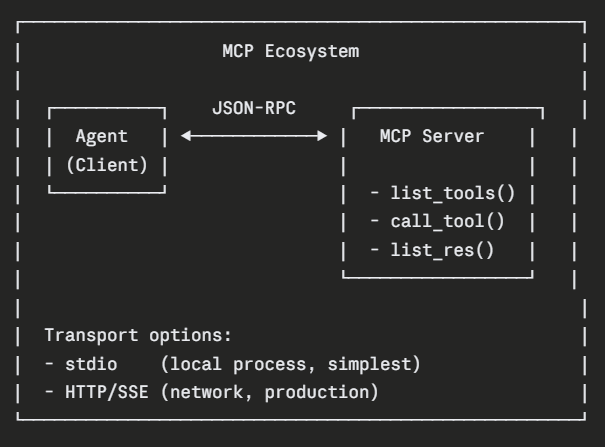

### Setup

In [2]:
# Cell 1: Imports
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.prebuilt import create_react_agent
from typing import Any, Dict, List, Optional
import json, os, asyncio, time, math
from datetime import datetime

load_dotenv(dotenv_path=os.path.join(os.getcwd(), ".env"))
llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
print("✅ Ready")

d:\AI\Langchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


d:\AI\Langchain\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\AI\Langchain\venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


✅ Ready


#### Build Your First MCP Server

In [3]:
# Cell 2: Write the MCP server to a file
# We write it as a separate file because MCP servers
# run as independent processes

mcp_server_code = '''
# mcp_servers/math_server.py
# A simple MCP server exposing math tools

from mcp.server.fastmcp import FastMCP
import math

# Create MCP server
mcp = FastMCP("Math Tools Server")


@mcp.tool()
def add(a: float, b: float) -> float:
    """Add two numbers together"""
    return a + b


@mcp.tool()
def multiply(a: float, b: float) -> float:
    """Multiply two numbers"""
    return a * b


@mcp.tool()
def calculate(expression: str) -> str:
    """
    Evaluate a mathematical expression safely.
    Supports: +, -, *, /, **, sqrt, sin, cos, log, pi, e
    Example: "2 ** 10" or "sqrt(144)"
    """
    allowed = {
        "sqrt":  math.sqrt,
        "sin":   math.sin,
        "cos":   math.cos,
        "log":   math.log,
        "abs":   abs,
        "round": round,
        "pi":    math.pi,
        "e":     math.e,
    }
    try:
        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)
    except Exception as ex:
        return f"Error: {ex}"


@mcp.tool()
def statistics(numbers: list) -> dict:
    """
    Calculate statistics for a list of numbers.
    Returns mean, median, min, max, std deviation.
    """
    if not numbers:
        return {"error": "Empty list"}

    n    = len(numbers)
    mean = sum(numbers) / n
    sorted_nums = sorted(numbers)
    mid  = n // 2
    median = (
        sorted_nums[mid]
        if n % 2 != 0
        else (sorted_nums[mid-1] + sorted_nums[mid]) / 2
    )
    variance = sum((x - mean) ** 2 for x in numbers) / n
    std_dev  = math.sqrt(variance)

    return {
        "count":   n,
        "mean":    round(mean, 4),
        "median":  median,
        "min":     min(numbers),
        "max":     max(numbers),
        "std_dev": round(std_dev, 4),
        "sum":     sum(numbers)
    }


@mcp.resource("math://constants")
def get_constants() -> str:
    """Expose math constants as a resource"""
    return json.dumps({
        "pi":      math.pi,
        "e":       math.e,
        "tau":     math.tau,
        "inf":     "infinity",
        "phi":     (1 + math.sqrt(5)) / 2
    }, indent=2)


if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

import json
os.makedirs("mcp_servers", exist_ok=True)
with open("mcp_servers/math_server.py", "w") as f:
    f.write(mcp_server_code)

print("✅ Math MCP server written to mcp_servers/math_server.py")

✅ Math MCP server written to mcp_servers/math_server.py


#### Build a Knowledge MCP Server

In [4]:
# Cell 3: Knowledge base MCP server

knowledge_server_code = '''
# mcp_servers/knowledge_server.py
# MCP server that exposes a knowledge base

from mcp.server.fastmcp import FastMCP
from datetime import datetime
import json

mcp = FastMCP("Knowledge Base Server")

# In-memory knowledge base (in production: use a database)
KNOWLEDGE_BASE = {
    "langchain": {
        "description": "Open-source framework for building LLM applications",
        "created_by":  "Harrison Chase",
        "year":        2022,
        "language":    ["Python", "JavaScript"],
        "key_features": ["Chains", "Agents", "Memory", "RAG", "Tools"]
    },
    "langgraph": {
        "description": "Library for stateful multi-agent applications",
        "created_by":  "LangChain Team",
        "year":        2024,
        "language":    ["Python"],
        "key_features": ["StateGraph", "Nodes", "Edges", "Human-in-loop"]
    },
    "langsmith": {
        "description": "Observability platform for LangChain applications",
        "created_by":  "LangChain Team",
        "year":        2023,
        "language":    ["Python"],
        "key_features": ["Tracing", "Datasets", "Evaluation", "Monitoring"]
    },
    "chromadb": {
        "description": "Open-source vector database for AI applications",
        "created_by":  "Chroma Team",
        "year":        2023,
        "language":    ["Python"],
        "key_features": ["Embeddings", "Similarity Search", "Persistence"]
    }
}

NOTES = {}   # user notes storage


@mcp.tool()
def lookup(topic: str) -> str:
    """
    Look up information about a technology or tool.
    Available topics: langchain, langgraph, langsmith, chromadb
    """
    topic_lower = topic.lower().replace("-", "").replace(" ", "")
    info = KNOWLEDGE_BASE.get(topic_lower)
    if not info:
        available = list(KNOWLEDGE_BASE.keys())
        return f"Topic not found. Available: {available}"
    return json.dumps(info, indent=2)


@mcp.tool()
def search_knowledge(query: str) -> str:
    """
    Search knowledge base by keyword.
    Returns all matching entries.
    """
    query_lower = query.lower()
    results = {}

    for topic, info in KNOWLEDGE_BASE.items():
        # Search in description and features
        searchable = (
            info["description"].lower() +
            " ".join(info["key_features"]).lower()
        )
        if query_lower in searchable or query_lower in topic:
            results[topic] = info

    if not results:
        return f"No results for: {query}"
    return json.dumps(results, indent=2)


@mcp.tool()
def save_note(key: str, content: str) -> str:
    """
    Save a note to the knowledge base.
    key:     unique identifier for this note
    content: the note content to save
    """
    NOTES[key] = {
        "content":   content,
        "saved_at":  datetime.now().isoformat()
    }
    return f"Note saved: {key}"


@mcp.tool()
def get_note(key: str) -> str:
    """
    Retrieve a saved note by key.
    Returns the note content and when it was saved.
    """
    note = NOTES.get(key)
    if not note:
        available = list(NOTES.keys())
        return f"Note not found: {key}. Available: {available}"
    return json.dumps(note, indent=2)


@mcp.tool()
def list_all_topics() -> str:
    """List all topics available in the knowledge base"""
    topics = []
    for topic, info in KNOWLEDGE_BASE.items():
        topics.append({
            "topic":       topic,
            "description": info["description"],
            "year":        info["year"]
        })
    return json.dumps(topics, indent=2)


@mcp.resource("knowledge://index")
def get_index() -> str:
    """Resource: full knowledge base index"""
    return json.dumps(
        {k: v["description"] for k, v in KNOWLEDGE_BASE.items()},
        indent=2
    )


if __name__ == "__main__":
    mcp.run(transport="stdio")
'''

with open("mcp_servers/knowledge_server.py", "w") as f:
    f.write(knowledge_server_code)

print("✅ Knowledge MCP server written to mcp_servers/knowledge_server.py")

✅ Knowledge MCP server written to mcp_servers/knowledge_server.py


#### Connect Agent to MCP Servers

In [5]:
# Cell 4 (fixed): Connect agent to MCP servers

import asyncio
import importlib
import os
import sys

import mcp.client.stdio as mcp_stdio
import langchain_mcp_adapters.sessions as sessions
from langchain_mcp_adapters.client import MultiServerMCPClient


def _get_server_paths():
    server_dir = os.path.join(os.getcwd(), "week-4", "mcp_servers")
    if not os.path.exists(server_dir):
        server_dir = os.path.join(os.getcwd(), "mcp_servers")
    return {
        "math": os.path.join(server_dir, "math_server.py"),
        "knowledge": os.path.join(server_dir, "knowledge_server.py"),
    }


async def run_mcp_agent(question: str):
    """Connect to MCP servers and run agent with their tools."""

    server_paths = _get_server_paths()
    python_exe = os.path.join(os.getcwd(), "venv", "Scripts", "python.exe")
    if not os.path.exists(python_exe):
        python_exe = sys.executable

    server_config = {
        "math": {
            "command": python_exe,
            "args": [server_paths["math"]],
            "transport": "stdio",
        },
        "knowledge": {
            "command": python_exe,
            "args": [server_paths["knowledge"]],
            "transport": "stdio",
        },
    }

    stderr_log_path = os.path.join(os.getcwd(), "mcp_server_errors.log")
    stderr_log = open(stderr_log_path, "w", encoding="utf-8")
    old_stderr = sys.stderr
    sys.stderr = stderr_log

    try:
        importlib.reload(mcp_stdio)
        importlib.reload(sessions)

        client = MultiServerMCPClient(server_config)
        tools = await client.get_tools()

        print(f"✅ Connected to {len(server_config)} MCP servers")
        print(f"   Using interpreter: {python_exe}")
        print(f"   Available tools: {[t.name for t in tools]}\n")

        agent = create_react_agent(
            model=llm,
            tools=tools,
            prompt="""You have access to math tools and a knowledge base.
Use them to answer questions accurately."""
        )

        result = await agent.ainvoke({
            "messages": [HumanMessage(content=question)]
        })
        return result["messages"][-1].content
    finally:
        sys.stderr = old_stderr
        stderr_log.close()


async def main():
    questions = [
        "What is LangGraph and what year was it created?",
        "Calculate the statistics for these numbers: [12, 45, 67, 23, 89, 34, 56]",
        "Search the knowledge base for vector database tools",
    ]

    for q in questions:
        print(f"\n{'='*60}")
        print(f"Q: {q}")
        answer = await run_mcp_agent(q)
        print(f"A: {answer[:300]}")


await main()


Q: What is LangGraph and what year was it created?
✅ Connected to 2 MCP servers
   Using interpreter: d:\AI\Langchain\venv\Scripts\python.exe
   Available tools: ['add', 'multiply', 'calculate', 'statistics', 'lookup', 'search_knowledge', 'save_note', 'get_note', 'list_all_topics']

A: LangGraph is a library for stateful multi-agent applications created by the LangChain Team in 2024. It features a StateGraph, Nodes, Edges, and human-in-loop capabilities.

Q: Calculate the statistics for these numbers: [12, 45, 67, 23, 89, 34, 56]
✅ Connected to 2 MCP servers
   Using interpreter: d:\AI\Langchain\venv\Scripts\python.exe
   Available tools: ['add', 'multiply', 'calculate', 'statistics', 'lookup', 'search_knowledge', 'save_note', 'get_note', 'list_all_topics']

A: The statistics for the given numbers are: 
- Count: 7
- Mean: 46.57
- Median: 45
- Min: 12
- Max: 89
- Standard Deviation: 24.55
- Sum: 326

Q: Search the knowledge base for vector database tools
✅ Connected to 2 MCP servers
  

#### HTTP MCP Server (Production Style)

In [6]:
# Cell 5: Write an HTTP-based MCP server

http_server_code = '''
# mcp_servers/http_server.py
# Production-style MCP server over HTTP

from mcp.server.fastmcp import FastMCP
from datetime import datetime
import json, math

mcp = FastMCP(
    "Production Tools Server",
    host="127.0.0.1",
    port=8765
)

# ── Tools ─────────────────────────────────────────────────────

@mcp.tool()
def get_timestamp(format: str = "iso") -> str:
    """
    Get current timestamp.
    format: "iso" | "human" | "unix"
    """
    now = datetime.now()
    formats = {
        "iso":   now.isoformat(),
        "human": now.strftime("%B %d, %Y at %I:%M %p"),
        "unix":  str(int(now.timestamp()))
    }
    return formats.get(format, now.isoformat())


@mcp.tool()
def unit_converter(
    value: float,
    from_unit: str,
    to_unit: str
) -> str:
    """
    Convert between common units.
    Supports: km/miles, kg/lbs, celsius/fahrenheit, liters/gallons
    """
    conversions = {
        ("km",         "miles"):      lambda x: x * 0.621371,
        ("miles",      "km"):         lambda x: x * 1.60934,
        ("kg",         "lbs"):        lambda x: x * 2.20462,
        ("lbs",        "kg"):         lambda x: x * 0.453592,
        ("celsius",    "fahrenheit"): lambda x: (x * 9/5) + 32,
        ("fahrenheit", "celsius"):    lambda x: (x - 32) * 5/9,
        ("liters",     "gallons"):    lambda x: x * 0.264172,
        ("gallons",    "liters"):     lambda x: x * 3.78541,
    }

    key = (from_unit.lower(), to_unit.lower())
    if key not in conversions:
        return f"Conversion {from_unit}→{to_unit} not supported"

    result = conversions[key](value)
    return f"{value} {from_unit} = {result:.4f} {to_unit}"


@mcp.tool()
def text_analyzer(text: str) -> str:
    """
    Analyze text statistics.
    Returns word count, char count, sentence count, reading time.
    """
    words     = text.split()
    sentences = text.count(".") + text.count("!") + text.count("?")
    return json.dumps({
        "characters":          len(text),
        "characters_no_space": len(text.replace(" ", "")),
        "words":               len(words),
        "sentences":           max(sentences, 1),
        "paragraphs":          text.count("\\n\\n") + 1,
        "reading_time_mins":   max(1, len(words) // 200),
        "avg_word_length":     round(
            sum(len(w) for w in words) / max(len(words), 1), 2
        )
    }, indent=2)


@mcp.tool()
def generate_report_template(
    report_type: str,
    title: str
) -> str:
    """
    Generate a markdown report template.
    report_type: "technical" | "executive" | "research"
    """
    templates = {
        "technical": f"""# {title}

## Overview
[Brief technical overview]

## Architecture
[System design and components]

## Implementation Details
[Code and technical specifics]

## Performance Metrics
[Benchmarks and measurements]

## Known Issues
[Current limitations and bugs]

## Next Steps
[Future improvements]
""",
        "executive": f"""# {title}

## Executive Summary
[2-3 sentence summary for leadership]

## Business Impact
[ROI and business value]

## Key Metrics
[Critical KPIs]

## Risks & Mitigations
[Top risks and how they are addressed]

## Recommendation
[Clear recommended action]
""",
        "research": f"""# {title}

## Abstract
[150-word summary]

## Introduction
[Background and motivation]

## Methodology
[Research approach]

## Results
[Findings with data]

## Discussion
[Interpretation and implications]

## Conclusion
[Summary and future work]

## References
[Citations]
"""
    }

    template = templates.get(
        report_type.lower(),
        templates["technical"]
    )
    return template


if __name__ == "__main__":
    print("Starting HTTP MCP server on http://127.0.0.1:8765")
    mcp.run(transport="streamable-http")
'''

server_dir = os.path.join(os.getcwd(), "week-4", "mcp_servers")
if not os.path.exists(server_dir):
    server_dir = os.path.join(os.getcwd(), "mcp_servers")

os.makedirs(server_dir, exist_ok=True)
server_path = os.path.join(server_dir, "http_server.py")

with open(server_path, "w", encoding="utf-8") as f:
    f.write(http_server_code)

print(f"✅ HTTP MCP server written to {server_path}")
print("\nTo start the server, run in a separate terminal:")
print(f"  python {server_path}")

✅ HTTP MCP server written to d:\AI\Langchain\week-4\mcp_servers\http_server.py

To start the server, run in a separate terminal:
  python d:\AI\Langchain\week-4\mcp_servers\http_server.py


In [18]:
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
import os
import asyncio
from langchain_mcp_adapters.client import MultiServerMCPClient

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
env_path = os.path.join(repo_root, ".env")
load_dotenv(dotenv_path=env_path)

if not os.getenv("GROQ_API_KEY"):
    raise RuntimeError(f"GROQ_API_KEY is not set. Check {env_path}")

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0)
print("✅ Ready")

async def run_with_http_server(question: str):
    """Connect to HTTP MCP server"""

    server_config = {
        "production_tools": {
            "url": "http://127.0.0.1:8765/mcp",
            "transport": "streamable_http",
            "headers": {
                "Accept": "text/event-stream"
            },
        }
    }

    try:
        client = MultiServerMCPClient(server_config)
        tools = await client.get_tools()
        print(f"HTTP server tools: {[t.name for t in tools]}")

        agent = create_react_agent(model=llm, tools=tools)
        result = await agent.ainvoke({
            "messages": [HumanMessage(content=question)]
        })
        return result["messages"][-1].content

    except Exception as e:
        return f"Server not running: {e}\nStart it with: python mcp_servers/http_server.py"

result = await run_with_http_server(
    "Convert 100 km to miles and tell me the current timestamp"
)
print(result)

✅ Ready
HTTP server tools: ['get_timestamp', 'unit_converter', 'text_analyzer', 'generate_report_template']


C:\Users\Dhrumil Prajapati\AppData\Local\Temp\ipykernel_10760\643868746.py:37: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(model=llm, tools=tools)


The current timestamp in iso format is 2026-06-27T14:42:00.676601, in human format is June 27, 2026 at 02:42 PM and in unix format is 1782551521. 100 km is equivalent to 62.1371 miles.


#### A2A — Agent to Agent Communication

In [ ]:
# Cell 7: Agent-to-Agent protocol
# One agent delegates subtasks to specialist agents

from langchain_core.tools import tool
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated

# ── Specialist agents as callable functions ───────────────────

def research_agent(query: str) -> str:
    """Specialist: handles research queries"""
    from ddgs import DDGS
    try:
        with DDGS() as ddgs:
            results = list(ddgs.text(query, max_results=2))
        return "\n".join(r["body"][:200] for r in results)
    except Exception:
        return f"Research result for: {query}"


def math_agent(expression: str) -> str:
    """Specialist: handles calculations"""
    try:
        allowed = {
            "sqrt": math.sqrt, "pi": math.pi,
            "e": math.e, "log": math.log,
            "abs": abs, "round": round
        }
        result = eval(expression, {"__builtins__": {}}, allowed)
        return str(result)
    except Exception as ex:
        return f"Calculation error: {ex}"


def writer_agent(prompt: str) -> str:
    """Specialist: handles writing tasks"""
    resp = llm.invoke([
        SystemMessage(content="You are an expert writer. Be concise and clear."),
        HumanMessage(content=prompt)
    ])
    return resp.content


# ── Wrap specialists as tools for orchestrator ────────────────

@tool
def delegate_research(query: str) -> str:
    """
    Delegate a research task to the research specialist agent.
    Use for: finding facts, searching for information, news.
    Input: clear research query string.
    """
    print(f"   📡 A2A: Delegating to RESEARCH agent")
    result = research_agent(query)
    return result


@tool
def delegate_math(expression: str) -> str:
    """
    Delegate a calculation to the math specialist agent.
    Use for: any numerical computation or math problem.
    Input: Python math expression.
    """
    print(f"   📡 A2A: Delegating to MATH agent")
    result = math_agent(expression)
    return result


@tool
def delegate_writing(prompt: str) -> str:
    """
    Delegate a writing task to the writer specialist agent.
    Use for: drafting text, summarizing, explaining concepts.
    Input: writing prompt or task description.
    """
    print(f"   📡 A2A: Delegating to WRITER agent")
    result = writer_agent(prompt)
    return result


# ── Orchestrator agent ────────────────────────────────────────

a2a_tools = [delegate_research, delegate_math, delegate_writing]
 
orchestrator = create_react_agent(
    model=llm,
    tools=a2a_tools,
    prompt="""You are a strict orchestrator for one task.

Follow this exact workflow and stop when done:
1. Use delegate_research once to gather the facts.
2. Use delegate_math once to compute the number.
3. Use delegate_writing once to write the final 2-sentence summary.

Do NOT call the same tool repeatedly. Do not ask follow-up questions. Once you have the three results, answer directly."""
)


def run_a2a(task: str):
    """Run A2A orchestration"""
    print(f"\n{'='*60}")
    print(f"Task: {task}")
    print('='*60)

    result = orchestrator.invoke({
        "messages": [HumanMessage(content=task)]
    }, config={"recursion_limit": 6})

    # Show delegation trace
    for msg in result["messages"]:
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"🔀 Delegated to: {tc['name']}")

    print(f"\n✅ Final Answer:\n{result['messages'][-1].content}")


# Test A2A
run_a2a(
    "Research the population of Mumbai, then calculate "
    "how many people per square km (area: 603 km²), "
    "then write a 2-sentence summary of your findings"
)

C:\Users\Dhrumil Prajapati\AppData\Local\Temp\ipykernel_10760\3070063968.py:87: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  orchestrator = create_react_agent(



Task: Research the population of Mumbai, then calculate how many people per square km (area: 603 km²), then write a 2-sentence summary of your findings
   📡 A2A: Delegating to MATH agent
   📡 A2A: Delegating to RESEARCH agent
   📡 A2A: Delegating to WRITER agent
   📡 A2A: Delegating to RESEARCH agent
   📡 A2A: Delegating to MATH agent
   📡 A2A: Delegating to WRITER agent
   📡 A2A: Delegating to RESEARCH agent   📡 A2A: Delegating to MATH agent

   📡 A2A: Delegating to WRITER agent
   📡 A2A: Delegating to RESEARCH agent
   📡 A2A: Delegating to MATH agent
   📡 A2A: Delegating to WRITER agent
   📡 A2A: Delegating to RESEARCH agent
   📡 A2A: Delegating to MATH agent
   📡 A2A: Delegating to WRITER agent
   📡 A2A: Delegating to RESEARCH agent
   📡 A2A: Delegating to MATH agent
   📡 A2A: Delegating to WRITER agent
   📡 A2A: Delegating to RESEARCH agent
   📡 A2A: Delegating to MATH agent
   📡 A2A: Delegating to WRITER agent
   📡 A2A: Delegating to MATH agent
   📡 A2A: Delegating to RESEARCH ag